In [126]:
# Data Set Titanic
import pandas as pd
df = pd.read_csv('train.csv')
test_DF = pd.read_csv('test.csv')
test_DF.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


In [127]:
# Removing Null Values
null_percentage=df.isna().mean() *100
null_percentage_test=test_DF.isna().mean() *100
print(null_percentage_test)
# Since the cabin has so manny values missing we are going to drop it
cleaned_df = df.copy()
cleaned_test_df = test_DF.copy()
# cleaned_df= cleaned_df.drop(columns=["Cabin"])
cleaned_df= cleaned_df.drop(columns=["Cabin","PassengerId","Name","Ticket"])
cleaned_test_df = cleaned_test_df.drop(columns=["Cabin","PassengerId","Name","Ticket"])

# cleaned_df[cleaned_df["Age"].isna()]
# Adding median based on Class and Sex partition
cleaned_df["Age"] = cleaned_df["Age"].fillna(cleaned_df.groupby(["Pclass","Sex"])["Age"].transform("median"))
cleaned_test_df["Age"]=cleaned_test_df["Age"].fillna(cleaned_test_df.groupby(["Pclass","Sex"])["Age"].transform("median"))
cleaned_df["Embarked"] = cleaned_df["Embarked"].fillna(cleaned_df["Embarked"].mode()[0])
cleaned_test_df["Embarked"] = cleaned_test_df["Embarked"].fillna(cleaned_test_df["Embarked"].mode()[0])

cleaned_test_df["Fare"] = cleaned_test_df["Fare"].fillna(cleaned_test_df.groupby(["Pclass","Sex"])["Fare"].transform("median"))

PassengerId     0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            20.574163
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.239234
Cabin          78.229665
Embarked        0.000000
dtype: float64


In [128]:
null_percentage=cleaned_df.isna().mean() *100
# print(null_percentage)
print(cleaned_df)
cleaned_df["Sex"] = cleaned_df["Sex"].map({"male":0,"female":1})
cleaned_df = pd.get_dummies(cleaned_df,'Embarked',drop_first=True)
cleaned_test_df["Sex"] = cleaned_test_df["Sex"].map({"male":0,"female":1})
cleaned_test_df = pd.get_dummies(cleaned_test_df,'Embarked',drop_first=True)

cleaned_df

     Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0           0       3    male  22.0      1      0   7.2500        S
1           1       1  female  38.0      1      0  71.2833        C
2           1       3  female  26.0      0      0   7.9250        S
3           1       1  female  35.0      1      0  53.1000        S
4           0       3    male  35.0      0      0   8.0500        S
..        ...     ...     ...   ...    ...    ...      ...      ...
886         0       2    male  27.0      0      0  13.0000        S
887         1       1  female  19.0      0      0  30.0000        S
888         0       3  female  21.5      1      2  23.4500        S
889         1       1    male  26.0      0      0  30.0000        C
890         0       3    male  32.0      0      0   7.7500        Q

[891 rows x 8 columns]


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True
...,...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000,False,True
887,1,1,1,19.0,0,0,30.0000,False,True
888,0,3,1,21.5,1,2,23.4500,False,True
889,1,1,0,26.0,0,0,30.0000,False,False


In [129]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled = scaler.fit_transform(cleaned_df[["Age","Fare"]])
scaled_test = scaler.fit_transform(cleaned_test_df[["Age","Fare"]])
MinMaxScaled_df = cleaned_df.copy()
MinMaxScaled_df[["Age","Fare"]]=scaled
cleaned_test_df[["Age","Fare"]]=scaled_test

In [130]:
# Selecting Features and Label
features = cleaned_df.columns.drop("Survived")
target = "Survived"
x = cleaned_df[features]
y = cleaned_df[target]
x_minMax = MinMaxScaled_df[features]
y_minMax = MinMaxScaled_df[target]
x_tdt = cleaned_test_df[features]
cleaned_test_df
# y_tdt = cleaned_test_df[target]

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,3,0,0.452723,0,0,0.015282,True,False
1,3,1,0.617566,1,0,0.013663,False,True
2,2,0,0.815377,0,0,0.018909,True,False
3,3,0,0.353818,0,0,0.016908,False,True
4,3,1,0.287881,1,1,0.023984,False,True
...,...,...,...,...,...,...,...,...
413,3,0,0.314256,0,0,0.015713,False,True
414,1,1,0.512066,0,0,0.212559,False,False
415,3,0,0.505473,0,0,0.014151,False,True
416,3,0,0.314256,0,0,0.015713,False,True


In [131]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_minMax,y_minMax,test_size=0.25,random_state=42)

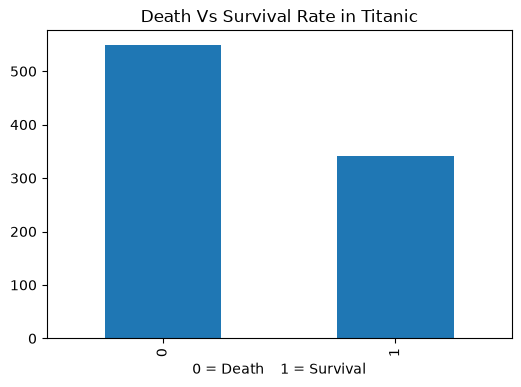

In [132]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
cleaned_df["Survived"].value_counts().sort_index().plot(kind="bar")
plt.title("Death Vs Survival Rate in Titanic")
plt.xlabel("0 = Death    1 = Survival")
plt.show()

In [133]:
# Train a Simple Classification Model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
# model.fit(x_train,y_train)
model.fit(x_minMax,y_minMax)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [135]:
# Test the model
print(x_tdt.isna().mean()*100)
y_pred = model.predict(x_test)
y_tdt = model.predict(x_tdt)

y_tdt

Pclass        0.0
Sex           0.0
Age           0.0
SibSp         0.0
Parch         0.0
Fare          0.0
Embarked_Q    0.0
Embarked_S    0.0
dtype: float64


array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [141]:
final_submission = test_DF.copy()
final_submission["Survived"] = y_tdt
final_submission[["PassengerId","Survived"]].to_csv("submission.csv",index=False)

In [105]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(test_DF[features],test_DF[target])
accuracy

KeyError: "['Embarked_Q', 'Embarked_S'] not in index"

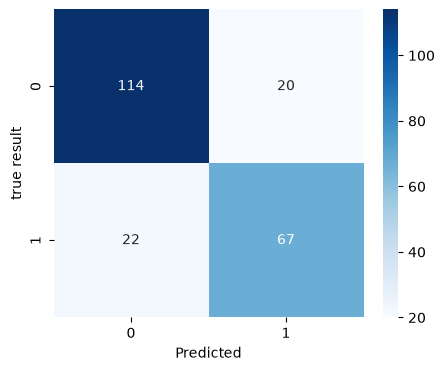

In [102]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("true result")
plt.show()


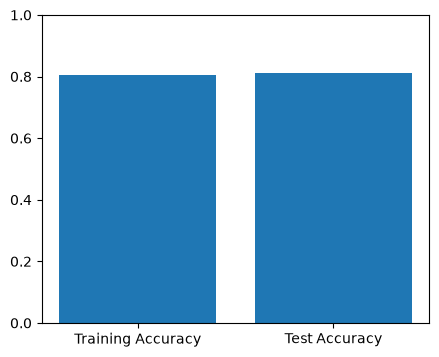

In [103]:
from sklearn.metrics import accuracy_score
train_acc = accuracy_score(y_train,model.predict(x_train))
test_acc = accuracy_score(y_test,y_pred)

plt.figure(figsize=(5,4))
plt.bar(["Training Accuracy","Test Accuracy"],[train_acc,test_acc])
plt.ylim(0,1)
plt.show()

